<center><b>EE (P) 533 Spring 2026<br>
Analog Circuits for Sensor Systems<br>
University of Washington Electrical & Computer Engineering</b></center>

<b>Design Project Phase 2: Strain Gage Low-Noise Signal Conditioning</b>

<u>*Phase 2 Design*</u>

__Design target__

The Phase 2 goal is to add the lowpass filter and choose the ADC. I kept the Phase 1 instrumentation amplifier gain and resistor values, then sized the filter from the Phase 1 input-referred noise density. The final check includes the filter noise bandwidth and ADC quantization noise.

The main design choices are:

- 4th-order Butterworth lowpass filter, implemented as two unity-gain Sallen-Key stages.
- Filter cutoff $f_c=13.5kHz$, so the attenuation at $10kHz$ is below $0.5dB$.
- ADS8326 16-bit SAR ADC, sampled at $100kS/s$ with a $5V$ reference range.

The LTspice screenshots should be added in the `screenshots/` folder and then the notebook should be rerun. If a screenshot is missing, the notebook shows a placeholder instead of failing.

In [1]:
import csv
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from scipy import signal
from scipy.io import wavfile

mpl.rcParams['font.size'] = 12
mpl.rcParams['legend.fontsize'] = 'large'

ROOT = Path.cwd()
if ROOT.name != 'Phase2_Submission':
    print('Notebook is expected to be run from Phase2_Submission/. Current directory:', ROOT)

SCREEN = Path('screenshots')
SCREEN.mkdir(exist_ok=True)

def show_image(path, caption=None, width=850):
    p = Path(path)
    if p.exists():
        display(Image(filename=str(p), width=width))
        if caption:
            display(Markdown(f'<center><b>{caption}</b></center>'))
    else:
        text = f'**Missing screenshot:** `{p}`'
        if caption:
            text += f'  \nExpected content: {caption}'
        display(Markdown(text))

def db(x):
    return 20*np.log10(np.maximum(np.abs(x), 1e-300))


__1) Instrumentation amplifier carried over from Phase 1__

The Phase 1 design used the three-op-amp instrumentation amplifier. The total gain is set by

$$
G_1=1+\frac{R_{fp}+R_{fm}}{R_G}, \qquad G_2=\frac{R_2}{R_1}, \qquad G_{tot}=G_1G_2.
$$

I used

$$
R_{fp}=R_{fm}=4.99k\Omega, \quad R_G=200\Omega, \quad R_1=10k\Omega, \quad R_2=19.6k\Omega.
$$

The bridge is modeled as a differential Thevenin source centered at $2.5V$. At zero strain each bridge output sees $500\Omega$ to AC ground, so the differential Thevenin resistance is approximately $1k\Omega$.

In [2]:
k = 1.380649e-23
T = 300
VDD = 5.0
R_bridge = 1e3
Vcm = VDD/2

Vpp_in = 20e-3
Vpp_out = 2.0
SNR_phase2 = 75
fsbw = 10e3

Rfp = Rfm = 4.99e3
RG = 200.0
R1 = 10e3
R2 = 19.6e3
G1 = 1 + (Rfp + Rfm)/RG
G2 = R2/R1
Gtot = G1*G2

print(f'G1 = {G1:.3f} V/V')
print(f'G2 = {G2:.3f} V/V')
print(f'Gtot = {Gtot:.3f} V/V = {20*np.log10(Gtot):.2f} dB')
print(f'Output signal from 20 mVpp bridge signal = {Gtot*Vpp_in:.4f} Vpp')


G1 = 50.900 V/V
G2 = 1.960 V/V
Gtot = 99.764 V/V = 39.98 dB
Output signal from 20 mVpp bridge signal = 1.9953 Vpp


The calculated gain is close enough to the required factor of 100. The full-scale output swing is centered at $2.5V$, so the signal at the ADC input is about $1.5V$ to $3.5V$.

__1.1 Amplifier schematic and DC operating point__

The schematic below is the Phase 1 amplifier screenshot. For the final run I will use the corrected Phase 1 schematic with $V_{ref}$ driven by the buffered 2.5 V node.

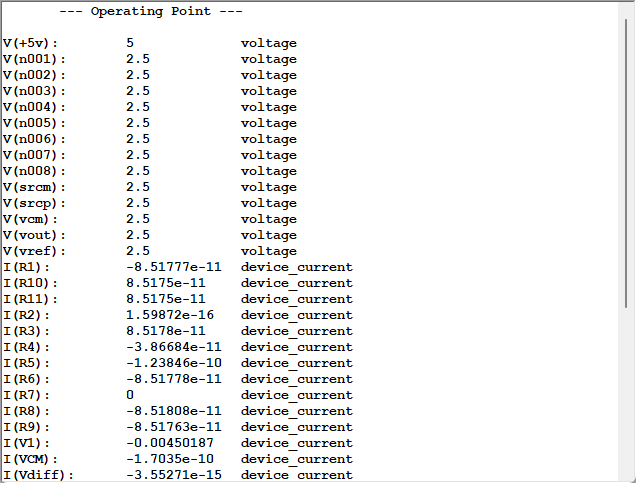

<center><b>Phase 1 amplifier operating point schematic.</b></center>

In [3]:
if Path('screenshots/phase1_amp_op.png').exists():
    show_image('screenshots/phase1_amp_op.png', 'Phase 1 amplifier operating point schematic.', width=850)
else:
    show_image('../ltSpice/phase1_op_schematic.png', 'Phase 1 amplifier operating point schematic.', width=850)

__1.2 Noise summary__

For the hand noise budget I used the ADA4528-2 typical values

$$
e_n=5.6nV/\sqrt{Hz}, \qquad i_n=0.7pA/\sqrt{Hz}.
$$

The dominant terms are the first two op amp voltage noise sources and the bridge thermal noise. The other resistor and second-stage terms are smaller because the first stage already provides most of the gain.

In [4]:
def en_res(R):
    return np.sqrt(4*k*T*R)

en_op = 5.6e-9
in_op = 0.7e-12
Rth_each = 500.0
Rth_diff = 1e3

noise_terms = {
    'Bridge thermal noise': en_res(Rth_diff),
    'U1/U2 voltage noise': np.sqrt(2)*en_op,
    'U1/U2 current noise': np.sqrt(2)*in_op*Rth_each,
    'R_G thermal noise': ((G1-1)/G1)*en_res(RG),
    'R_fp/R_fm thermal noise': np.sqrt(2)*en_res(Rfp)/G1,
    'Second-stage resistors': np.sqrt(2*en_res(R2)**2 + 2*(G2*en_res(R1))**2)/Gtot,
    'U3 voltage noise': (1+G2)*en_op/Gtot,
    'U3 current noise': np.sqrt((in_op*R2)**2 + (in_op*(R1*R2/(R1+R2)))**2)/Gtot,
    'Vref buffer voltage noise': en_op/Gtot,
}

total_en_in = np.sqrt(sum(v**2 for v in noise_terms.values()))
noise_df = pd.DataFrame({
    'source': list(noise_terms.keys()),
    'input_referred_density_nV_rtHz': [v*1e9 for v in noise_terms.values()],
    'percent_of_noise_power': [(v/total_en_in)**2*100 for v in noise_terms.values()],
})
noise_df.loc[len(noise_df)] = ['Total', total_en_in*1e9, 100.0]
noise_df


,source,input_referred_density_nV_rtHz,percent_of_noise_power
0,Bridge thermal noise,4.070355,19.954885
1,U1/U2 voltage noise,7.919596,75.542396
2,U1/U2 current noise,0.494975,0.295087
3,R_G thermal noise,1.784555,3.835701
4,R_fp/R_fm thermal noise,0.252627,0.076868
5,Second-stage resistors,0.439488,0.232637
6,U3 voltage noise,0.166152,0.033250
7,U3 current noise,0.145161,0.025379
8,Vref buffer voltage noise,0.056132,0.003795
9,Total,9.111873,100.000000


In [5]:
Vsig_in_rms = Vpp_in/(2*np.sqrt(2))
Vn_phase1_10k = total_en_in*np.sqrt(fsbw)
SNR_phase1_white = 20*np.log10(Vsig_in_rms/Vn_phase1_10k)

en_out = total_en_in*Gtot
print(f'Calculated input-referred white noise density = {total_en_in*1e9:.3f} nV/sqrt(Hz)')
print(f'Calculated output white noise density before filter = {en_out*1e6:.3f} uV/sqrt(Hz)')
print(f'White-noise estimate from 0.1 Hz to 10 kHz = {Vn_phase1_10k*1e6:.3f} uVrms input-referred')
print(f'Phase 1 white-noise SNR estimate = {SNR_phase1_white:.2f} dB')


Calculated input-referred white noise density = 9.112 nV/sqrt(Hz)
Calculated output white noise density before filter = 0.909 uV/sqrt(Hz)
White-noise estimate from 0.1 Hz to 10 kHz = 0.911 uVrms input-referred
Phase 1 white-noise SNR estimate = 77.80 dB


__1.3 Unfiltered LTspice noise simulation__

For the final submission this screenshot should be rerun from $0.01Hz$ to $100MHz$ without the lowpass filter. In the `.noise` run, the differential input source must be `AC 1`; otherwise the input-referred noise curve can be wrong.

The rms value from this run is the value to compare against the Python noise source used for the transient simulation.

In [6]:
show_image('screenshots/phase1_unfiltered_noise.png', 'Unfiltered amplifier output noise from 0.01 Hz to 100 MHz, with LTspice total rms value.', width=900)

**Missing screenshot:** `screenshots/phase1_unfiltered_noise.png`  
Expected content: Unfiltered amplifier output noise from 0.01 Hz to 100 MHz, with LTspice total rms value.

__1.4 Amplifier component table__

I used the same amplifier BOM from Phase 1, with currently visible high-volume DigiKey prices where available. The bridge itself is treated as the sensor, so it is not counted as an electronics BOM item.

In [7]:
amp_bom = pd.DataFrame([
    ['ADA4528-2ARMZ-R7', 'dual zero-drift RRIO op amp', 2, 3.58124, 'U1, U2, U3, Vref buffer', 'https://www.digikey.com/en/products/detail/analog-devices-inc/ADA4528-2ARMZ-R7/3771116'],
    ['RP0603BRE07200RL', '200 ohm, 0.1%, 0603 thin film', 1, 0.06463, 'R_G', 'DigiKey listing'],
    ['RT0603BRB074K99L', '4.99 kohm, 0.1%, 0603 thin film', 2, 0.14761, 'R_fp, R_fm', 'DigiKey listing'],
    ['RT0603BRE0710KL', '10 kohm, 0.1%, 0603 thin film', 4, 0.04770, 'two R1 plus Vref divider', 'DigiKey listing'],
    ['RT0603BRD0719K6L', '19.6 kohm, 0.1%, 0603 thin film', 2, 0.03949, 'two R2', 'DigiKey listing'],
], columns=['part', 'description', 'qty', 'unit_price_USD', 'use', 'link'])
amp_bom['extended_USD'] = amp_bom['qty']*amp_bom['unit_price_USD']
amp_bom


,part,description,qty,unit_price_USD,use,link,extended_USD
0,ADA4528-2ARMZ-R7,dual zero-drift RRIO op amp,2,3.58124,"U1, U2, U3, Vref buffer",https://www.digikey.com/en/products/detail/ana...,7.16248
1,RP0603BRE07200RL,"200 ohm, 0.1%, 0603 thin film",1,0.06463,R_G,DigiKey listing,0.06463
2,RT0603BRB074K99L,"4.99 kohm, 0.1%, 0603 thin film",2,0.14761,"R_fp, R_fm",DigiKey listing,0.29522
3,RT0603BRE0710KL,"10 kohm, 0.1%, 0603 thin film",4,0.04770,two R1 plus Vref divider,DigiKey listing,0.19080
4,RT0603BRD0719K6L,"19.6 kohm, 0.1%, 0603 thin film",2,0.03949,two R2,DigiKey listing,0.07898


__2) Lowpass filter design__

The Phase 2 SNR requirement is based on the $2V_{pp}$ output signal:

$$
V_{sig,rms}=\frac{2V}{2\sqrt{2}}=0.707V.
$$

For $75dB$ SNR, the maximum output rms noise is

$$
V_{n,out,max}=\frac{V_{sig,rms}}{10^{75/20}}.
$$

Using the Phase 1 output noise density, the maximum equivalent noise bandwidth is

$$
f_{enb,max}=\left(\frac{V_{n,out,max}}{e_{n,out}}\right)^2.
$$

I selected a 4th-order Butterworth filter. A 2nd-order Butterworth is too close to the ENBW limit, so the 4th-order design gives more margin without adding too many parts.

In [8]:
Vsig_out_rms = Vpp_out/(2*np.sqrt(2))
Vn_out_max = Vsig_out_rms/10**(SNR_phase2/20)
fenb_max = (Vn_out_max/en_out)**2

Nf = 4
fc = 13.5e3
atten_10k_db = -10*np.log10(1 + (10e3/fc)**(2*Nf))
# 4th-order Butterworth ENBW factor from numerical integration / standard table
w = 2*np.pi*np.logspace(-1, 8, 120000)
z, p, kval = signal.butter(Nf, 2*np.pi*fc, analog=True, output='zpk')
freq = w/(2*np.pi)
_, h = signal.freqs_zpk(z, p, kval, w)
fenb = np.trapezoid(np.abs(h)**2, freq)
Vn_out_filter = en_out*np.sqrt(fenb)
SNR_analog = 20*np.log10(Vsig_out_rms/Vn_out_filter)

print(f'Max allowed output noise for 75 dB SNR = {Vn_out_max*1e6:.2f} uVrms')
print(f'Max allowed ENBW = {fenb_max/1e3:.2f} kHz')
print(f'Chosen Butterworth cutoff = {fc/1e3:.2f} kHz')
print(f'Attenuation at 10 kHz = {-atten_10k_db:.3f} dB')
print(f'Filter ENBW = {fenb/1e3:.2f} kHz')
print(f'Estimated filtered output noise = {Vn_out_filter*1e6:.2f} uVrms')
print(f'Analog SNR before ADC quantization = {SNR_analog:.2f} dB')


Max allowed output noise for 75 dB SNR = 125.74 uVrms
Max allowed ENBW = 19.13 kHz
Chosen Butterworth cutoff = 13.50 kHz
Attenuation at 10 kHz = 0.377 dB
Filter ENBW = 13.85 kHz
Estimated filtered output noise = 106.99 uVrms
Analog SNR before ADC quantization = 76.40 dB


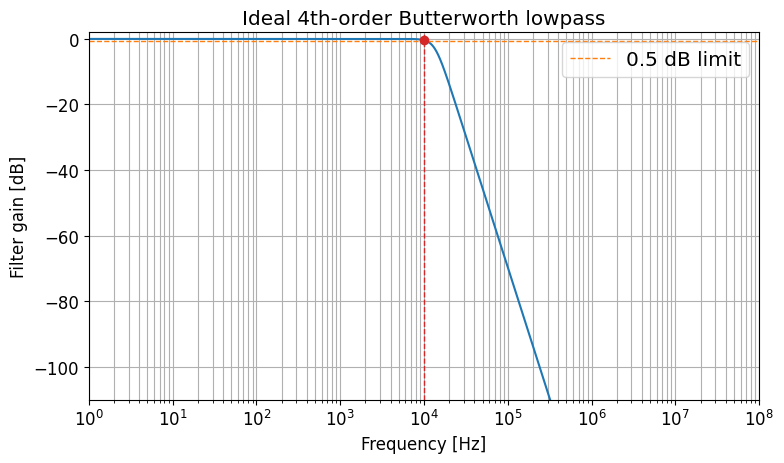

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.semilogx(freq, db(h), color='tab:blue')
ax.axvline(10e3, color='tab:red', linestyle='--', linewidth=1)
ax.axhline(-0.5, color='tab:orange', linestyle='--', linewidth=1, label='0.5 dB limit')
ax.scatter([10e3], [db(signal.freqs_zpk(z, p, kval, [2*np.pi*10e3])[1][0])], color='tab:red', zorder=3)
ax.set_xlim(1, 100e6)
ax.set_ylim(-110, 2)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Filter gain [dB]')
ax.set_title('Ideal 4th-order Butterworth lowpass')
ax.grid(True, which='both')
ax.legend()
plt.tight_layout()
plt.show()


__2.1 Sallen-Key stage values__

For a unity-gain Sallen-Key stage with equal resistors,

$$
f_0=\frac{1}{2\pi R\sqrt{C_1C_2}}, \qquad Q=\frac{1}{2}\sqrt{\frac{C_1}{C_2}}.
$$

The two pole-pair Q values for a 4th-order Butterworth response are $0.541$ and $1.307$. I used $R=10k\Omega$ in both stages and solved for the capacitors.

In [10]:
butter_Q = np.array([0.5411961, 1.30656296])
Rfilt = 10e3
stage_rows = []
for i, Q in enumerate(butter_Q, start=1):
    Cshunt = 1/(4*np.pi*Rfilt*fc*Q)
    Cfb = Q/(np.pi*Rfilt*fc)
    f0_check = 1/(2*np.pi*Rfilt*np.sqrt(Cfb*Cshunt))
    Q_check = 0.5*np.sqrt(Cfb/Cshunt)
    stage_rows.append([i, Q_check, Rfilt, Rfilt, Cfb, Cshunt, f0_check])

stage_df = pd.DataFrame(stage_rows, columns=['stage', 'Q', 'R1_ohm', 'R2_ohm', 'Cfeedback_F', 'Cshunt_F', 'f0_Hz'])
stage_df['Cfeedback_display'] = stage_df['Cfeedback_F'].map(lambda x: f'{x*1e9:.3f} nF' if x > 1e-9 else f'{x*1e12:.1f} pF')
stage_df['Cshunt_display'] = stage_df['Cshunt_F'].map(lambda x: f'{x*1e9:.3f} nF' if x > 1e-9 else f'{x*1e12:.1f} pF')
stage_df[['stage', 'Q', 'R1_ohm', 'R2_ohm', 'Cfeedback_display', 'Cshunt_display', 'f0_Hz']]


,stage,Q,R1_ohm,R2_ohm,Cfeedback_display,Cshunt_display,f0_Hz
0,1,0.541196,10000.0,10000.0,1.276 nF,1.089 nF,13500.0
1,2,1.306563,10000.0,10000.0,3.081 nF,451.2 pF,13500.0


__2.2 Filter schematic and DC simulation__

The filter is biased around the same buffered $2.5V$ reference. The shunt capacitors go to the buffered reference node, which is AC ground for the filter but keeps the single-supply DC bias consistent.

In [11]:
show_image('screenshots/filter_op.png', 'Standalone filter schematic with component values and DC node voltages.', width=900)

**Missing screenshot:** `screenshots/filter_op.png`  
Expected content: Standalone filter schematic with component values and DC node voltages.

__2.3 Filter design description__

The low-Q Sallen-Key section is first and the high-Q section is second. The filter gain is unity in the passband, so it does not change the full-scale signal range set by the instrumentation amplifier. The cutoff is intentionally above $10kHz$; this keeps the attenuation at the passband edge below the $0.5dB$ limit while still keeping the equivalent noise bandwidth below the maximum allowed value.

__2.4 LTspice AC simulation__

The LTspice AC run should use $0.1Hz$ to $100MHz$. The plot should show `dB(V(fout)/V(fin))`, with the cursor at $10kHz$. The expected value is about $-0.38dB$. The equivalent noise bandwidth target from the ideal model is about $13.85kHz$.

In [12]:
show_image('screenshots/filter_ac.png', 'Standalone filter AC response from 0.1 Hz to 100 MHz, cursor at 10 kHz, and ENBW measurement.', width=900)

**Missing screenshot:** `screenshots/filter_ac.png`  
Expected content: Standalone filter AC response from 0.1 Hz to 100 MHz, cursor at 10 kHz, and ENBW measurement.

__2.5 Filter component table__

In [13]:
filter_bom = pd.DataFrame([
    ['ADA4661-2ARMZ-R7', 'dual RRIO CMOS op amp, 4 MHz GBW', 1, 2.34335, 'two Sallen-Key stages', 'https://www.digikey.com/en/products/detail/analog-devices-inc/ADA4661-2ARMZ-R7/4376374'],
    ['10 kOhm 0.1% thin-film resistor', '0603 thin film', 4, 0.04770, 'filter R1/R2', 'DigiKey listing'],
    ['1.276 nF C0G capacitor', 'C0G/NP0, use nearest available or parallel values', 1, 0.08000, 'stage 1 feedback C', 'DigiKey listing'],
    ['1.089 nF C0G capacitor', 'C0G/NP0, use nearest available or parallel values', 1, 0.08000, 'stage 1 shunt C', 'DigiKey listing'],
    ['3.081 nF C0G capacitor', 'C0G/NP0, use nearest available or parallel values', 1, 0.10000, 'stage 2 feedback C', 'DigiKey listing'],
    ['451.2 pF C0G capacitor', 'C0G/NP0, use nearest available value', 1, 0.06000, 'stage 2 shunt C', 'DigiKey listing'],
], columns=['part', 'description', 'qty', 'unit_price_USD', 'use', 'link'])
filter_bom['extended_USD'] = filter_bom['qty']*filter_bom['unit_price_USD']
filter_bom


,part,description,qty,unit_price_USD,use,link,extended_USD
0,ADA4661-2ARMZ-R7,"dual RRIO CMOS op amp, 4 MHz GBW",1,2.34335,two Sallen-Key stages,https://www.digikey.com/en/products/detail/ana...,2.34335
1,10 kOhm 0.1% thin-film resistor,0603 thin film,4,0.04770,filter R1/R2,DigiKey listing,0.19080
2,1.276 nF C0G capacitor,"C0G/NP0, use nearest available or parallel values",1,0.08000,stage 1 feedback C,DigiKey listing,0.08000
3,1.089 nF C0G capacitor,"C0G/NP0, use nearest available or parallel values",1,0.08000,stage 1 shunt C,DigiKey listing,0.08000
4,3.081 nF C0G capacitor,"C0G/NP0, use nearest available or parallel values",1,0.10000,stage 2 feedback C,DigiKey listing,0.10000
5,451.2 pF C0G capacitor,"C0G/NP0, use nearest available value",1,0.06000,stage 2 shunt C,DigiKey listing,0.06000


__3) ADC selection__

The ADC should not dominate the noise. With a $5V$ ADC reference, the rms quantization noise is

$$
V_{q,rms}=\frac{5V}{2^N\sqrt{12}}.
$$

A 14-bit ADC is too close to the limit. A 16-bit ADC gives about $22\mu V_{rms}$ quantization noise, which is much smaller than the filtered analog noise. I chose the TI ADS8326 because it is a 16-bit SAR ADC with a 250 kS/s maximum sample rate, SPI output, external reference, and 2.7 V to 5.5 V supply compatibility. The actual simulation uses $100kS/s$, which is well above $2\times10kHz$ and gives a reasonable anti-alias transition band.

In [14]:
bits_list = np.array([12, 14, 15, 16, 18, 24])
adc_rows = []
for bits in bits_list:
    q_rms = VDD/(2**bits*np.sqrt(12))
    total_noise = np.sqrt(Vn_out_filter**2 + q_rms**2)
    snr = 20*np.log10(Vsig_out_rms/total_noise)
    adc_rows.append([bits, q_rms*1e6, total_noise*1e6, snr])
adc_df = pd.DataFrame(adc_rows, columns=['N_bits', 'quant_noise_uVrms', 'analog_plus_quant_uVrms', 'SNR_dB'])
adc_df


,N_bits,quant_noise_uVrms,analog_plus_quant_uVrms,SNR_dB
0,12,352.386639,368.271541,65.666337
1,14,88.096660,138.595116,74.154742
2,15,44.048330,115.705834,75.722595
3,16,22.024165,109.236662,76.222332
4,18,5.506041,107.134967,76.391075
5,24,0.086032,106.993420,76.402559


In [15]:
adc_bom = pd.DataFrame([
    ['ADS8326IDGKT', '16-bit SAR ADC, 250 kS/s max, SPI, external reference', 1, 12.43333, 'ADC, operated at 100 kS/s', 'https://www.digikey.com/en/products/detail/texas-instruments/ADS8326IDGKT/1632612'],
], columns=['part', 'description', 'qty', 'unit_price_USD', 'use', 'link'])
adc_bom['extended_USD'] = adc_bom['qty']*adc_bom['unit_price_USD']
adc_bom


,part,description,qty,unit_price_USD,use,link,extended_USD
0,ADS8326IDGKT,"16-bit SAR ADC, 250 kS/s max, SPI, external re...",1,12.43333,"ADC, operated at 100 kS/s",https://www.digikey.com/en/products/detail/tex...,12.43333


__3.1 Complete schematic, DC operating point, and power__

The complete schematic should show the bridge, instrumentation amplifier, lowpass filter, the buffered reference node, and an ADC label. The ADC is included in the BOM and power table, but the quantization is modeled in Python.

In [16]:
show_image('screenshots/top_level_op_power.png', 'Complete top-level schematic with DC node voltages and supply-current/power annotations.', width=950)

**Missing screenshot:** `screenshots/top_level_op_power.png`  
Expected content: Complete top-level schematic with DC node voltages and supply-current/power annotations.

__3.2 Top-level cost table__

For ICs I used the largest visible DigiKey price tier from the product pages. For a real 10,000-unit build, the exact cost would normally come from a quote, but this is a consistent estimate for comparing the design.

In [17]:
top_bom = pd.concat([amp_bom, filter_bom, adc_bom], ignore_index=True)
top_bom_summary = top_bom[['part', 'description', 'qty', 'unit_price_USD', 'extended_USD', 'use', 'link']]
total_cost = top_bom_summary['extended_USD'].sum()
display(top_bom_summary)
print(f'Estimated electronics cost per unit = ${total_cost:.2f}')


,part,description,qty,unit_price_USD,extended_USD,use,link
0,ADA4528-2ARMZ-R7,dual zero-drift RRIO op amp,2,3.58124,7.16248,"U1, U2, U3, Vref buffer",https://www.digikey.com/en/products/detail/ana...
1,RP0603BRE07200RL,"200 ohm, 0.1%, 0603 thin film",1,0.06463,0.06463,R_G,DigiKey listing
2,RT0603BRB074K99L,"4.99 kohm, 0.1%, 0603 thin film",2,0.14761,0.29522,"R_fp, R_fm",DigiKey listing
3,RT0603BRE0710KL,"10 kohm, 0.1%, 0603 thin film",4,0.04770,0.19080,two R1 plus Vref divider,DigiKey listing
4,RT0603BRD0719K6L,"19.6 kohm, 0.1%, 0603 thin film",2,0.03949,0.07898,two R2,DigiKey listing
5,ADA4661-2ARMZ-R7,"dual RRIO CMOS op amp, 4 MHz GBW",1,2.34335,2.34335,two Sallen-Key stages,https://www.digikey.com/en/products/detail/ana...
6,10 kOhm 0.1% thin-film resistor,0603 thin film,4,0.04770,0.19080,filter R1/R2,DigiKey listing
7,1.276 nF C0G capacitor,"C0G/NP0, use nearest available or parallel values",1,0.08000,0.08000,stage 1 feedback C,DigiKey listing
8,1.089 nF C0G capacitor,"C0G/NP0, use nearest available or parallel values",1,0.08000,0.08000,stage 1 shunt C,DigiKey listing
9,3.081 nF C0G capacitor,"C0G/NP0, use nearest available or parallel values",1,0.10000,0.10000,stage 2 feedback C,DigiKey listing


Estimated electronics cost per unit = $23.08


__3.3 Power dissipation table__

The bridge current is included because it is driven from the same 5 V supply. Filter resistor DC current is negligible because the Sallen-Key capacitors are open at DC and the op amp input current is small.

In [18]:
power_rows = [
    ['Wheatstone bridge', VDD/1e3, VDD*(VDD/1e3), '1 kOhm bridge equivalent supply current'],
    ['ADA4528-2 amplifier channels', 4*1.5e-3, VDD*(4*1.5e-3), 'U1, U2, U3, Vref buffer'],
    ['Vref divider', VDD/(2*10e3), VDD*(VDD/(2*10e3)), 'two 10 kOhm resistors'],
    ['ADA4661-2 filter channels', 2*0.63e-3, VDD*(2*0.63e-3), 'two Sallen-Key op amps'],
    ['ADS8326 ADC', 10e-3/VDD, 10e-3, 'typical 10 mW at full data rate'],
]
power_df = pd.DataFrame(power_rows, columns=['block', 'current_A', 'power_W', 'note'])
power_df.loc[len(power_df)] = ['Total', power_df['current_A'].sum(), power_df['power_W'].sum(), '']
power_df['current_mA'] = power_df['current_A']*1e3
power_df['power_mW'] = power_df['power_W']*1e3
power_df[['block', 'current_mA', 'power_mW', 'note']]


,block,current_mA,power_mW,note
0,Wheatstone bridge,5.00,25.00,1 kOhm bridge equivalent supply current
1,ADA4528-2 amplifier channels,6.00,30.00,"U1, U2, U3, Vref buffer"
2,Vref divider,0.25,1.25,two 10 kOhm resistors
3,ADA4661-2 filter channels,1.26,6.30,two Sallen-Key op amps
4,ADS8326 ADC,2.00,10.00,typical 10 mW at full data rate
5,Total,14.51,72.55,


__3.4 Top-level AC simulation__

The full-circuit AC result should include the instrumentation amplifier and the filter. The low-frequency gain should be close to $40dB$, and the value at $10kHz$ should be about $40dB-0.38dB$.

In [19]:
show_image('screenshots/top_level_ac.png', 'Full-circuit AC response from 0.1 Hz to 100 MHz, with cursor at 10 kHz.', width=900)

**Missing screenshot:** `screenshots/top_level_ac.png`  
Expected content: Full-circuit AC response from 0.1 Hz to 100 MHz, with cursor at 10 kHz.

__3.5 Top-level noise simulation__

For LTspice, run

```text
.noise V(fout) Vdiff dec 100 0.1 100Meg
```

with the differential input source set to `AC 1`. Plot `V(inoise)` to report the input-referred density at $10kHz$, and use `V(onoise)` or the error log for the total output rms noise at the filter output.

In [20]:
show_image('screenshots/top_level_noise.png', 'Full-circuit noise simulation: input-referred density at 10 kHz and total integrated output noise.', width=900)

**Missing screenshot:** `screenshots/top_level_noise.png`  
Expected content: Full-circuit noise simulation: input-referred density at 10 kHz and total integrated output noise.

__3.6 Time-domain simulation and ADC quantization__

The Python code below creates the noise input file for LTspice. The noise source represents the unfiltered instrumentation amplifier output noise from DC to $500kHz$:

$$
V_{n,rms}=e_{n,out}\sqrt{500kHz}.
$$

Run this cell once before the LTspice transient simulation so that `input_noise_phase2.csv` exists. After LTspice exports `sampled_noise_phase2.wav`, rerun this notebook. If the WAV file is not present, the notebook uses the same ideal filter model in Python as a fallback.

Generated input_noise_phase2.csv with 100000 samples
Noise source rms = 0.641 mVrms
Target rms = 0.643 mVrms


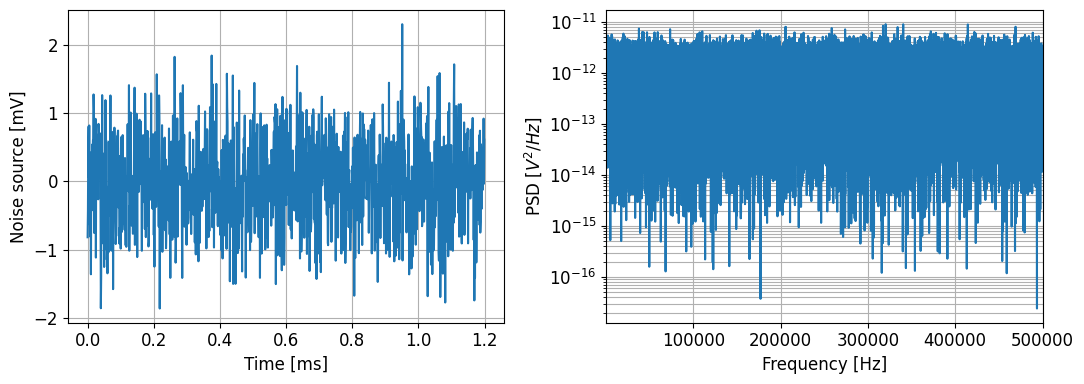

In [21]:
rng = np.random.default_rng(5332)
fenb_source = 500e3
fs_sim = 2*fenb_source
Tsim = 100e-3
Nsim = int(Tsim*fs_sim)
t = np.arange(Nsim)/fs_sim
vn_rms_source = en_out*np.sqrt(fenb_source)

vn_in = rng.normal(0, vn_rms_source, size=Nsim)
with open('input_noise_phase2.csv', 'w', newline='') as f:
    writer = csv.writer(f, delimiter='\t')
    writer.writerows(zip(t, vn_in))

print(f'Generated input_noise_phase2.csv with {Nsim} samples')
print(f'Noise source rms = {np.std(vn_in)*1e3:.3f} mVrms')
print(f'Target rms = {vn_rms_source*1e3:.3f} mVrms')

f_in, psd_in = signal.periodogram(vn_in, fs_sim)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t[:1200]*1e3, vn_in[:1200]*1e3)
ax[0].set_xlabel('Time [ms]')
ax[0].set_ylabel('Noise source [mV]')
ax[0].grid(True)
ax[1].semilogy(f_in[1:], psd_in[1:])
ax[1].set_xlim(1, 500e3)
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel(r'PSD [$V^2/Hz$]')
ax[1].grid(True, which='both')
plt.tight_layout()
plt.show()


Data source: Python ideal-filter fallback
ADC sample rate = 100.0 kS/s
ADC bits = 16, LSB = 76.29 uV
Signal rms = 0.707143 V
Total noise rms from time domain = 107.12 uVrms
Total noise rms from PSD = 107.12 uVrms
Measured SNR after ADC = 76.39 dB


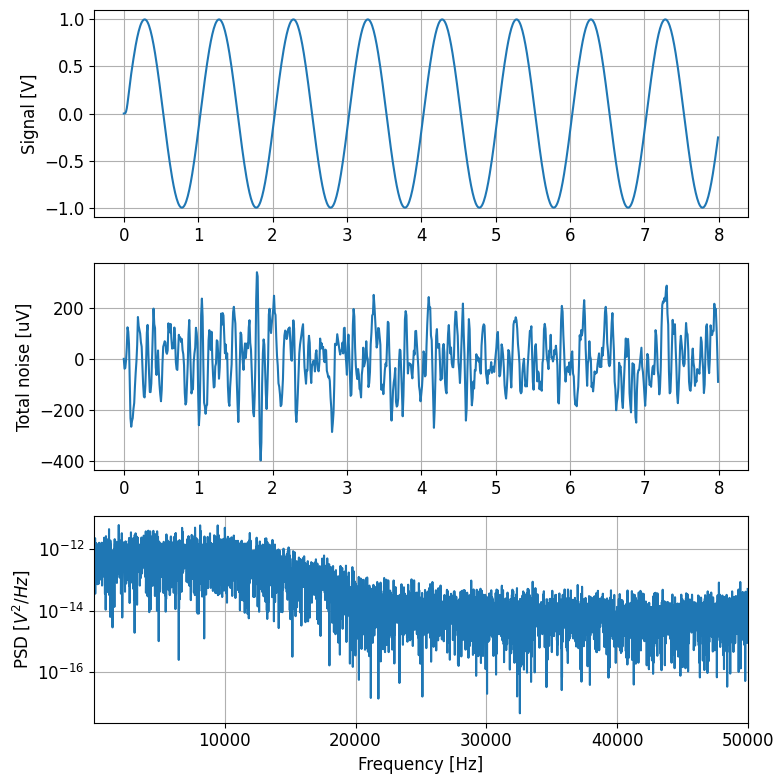

In [22]:
# Python fallback for the LTspice .wave file.
# The actual final result should use sampled_noise_phase2.wav exported by LTspice.
zd, pdig, kdig = signal.bilinear_zpk(z, p, kval, fs=fs_sim)
sos_dig = signal.zpk2sos(zd, pdig, kdig)

vn_filt = signal.sosfilt(sos_dig, vn_in)
vsig_in = np.sin(2*np.pi*1e3*t)      # 2 Vpp signal, shifted around 2.5 V in LTspice
vsig_filt = signal.sosfilt(sos_dig, vsig_in)

fs_adc = 100e3
decim = int(fs_sim/fs_adc)
time_py = t[::decim]
vn_py = vn_filt[::decim]
vsig_py = vsig_filt[::decim]

wav_path = Path('sampled_noise_phase2.wav')
if wav_path.exists():
    samplerate, data = wavfile.read(wav_path)
    data = np.asarray(data)
    time = np.arange(data.shape[0])/samplerate
    vn_meas = data[:, 0].astype(float)/2**31
    vsig_meas = data[:, 1].astype(float)/2**31
    source_used = 'LTspice WAV file'
else:
    samplerate = int(fs_adc)
    time = time_py
    vn_meas = vn_py
    vsig_meas = vsig_py
    source_used = 'Python ideal-filter fallback'

N_bits = 16
vref_adc = 5.0
lsb = vref_adc/2**N_bits
v_meas = vsig_meas + vn_meas
v_quantized = np.round(v_meas/lsb)*lsb
vn_tot = v_quantized - vsig_meas

settle = time > 10e-3
vsig_rms_meas = np.std(vsig_meas[settle])
vn_rms_td = np.std(vn_tot[settle])
SNR_meas = 20*np.log10(vsig_rms_meas/vn_rms_td)

f_psd, en_psd = signal.periodogram(vn_tot[settle], samplerate)
df_psd = f_psd[1] - f_psd[0]
vn_rms_psd = np.sqrt(np.sum(en_psd)*df_psd)

print('Data source:', source_used)
print(f'ADC sample rate = {samplerate/1e3:.1f} kS/s')
print(f'ADC bits = {N_bits}, LSB = {lsb*1e6:.2f} uV')
print(f'Signal rms = {vsig_rms_meas:.6f} V')
print(f'Total noise rms from time domain = {vn_rms_td*1e6:.2f} uVrms')
print(f'Total noise rms from PSD = {vn_rms_psd*1e6:.2f} uVrms')
print(f'Measured SNR after ADC = {SNR_meas:.2f} dB')

fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=False)
show_n = min(len(time), int(8e-3*samplerate))
ax[0].plot(time[:show_n]*1e3, vsig_meas[:show_n])
ax[0].set_ylabel('Signal [V]')
ax[0].grid(True)
ax[1].plot(time[:show_n]*1e3, vn_tot[:show_n]*1e6)
ax[1].set_ylabel('Total noise [uV]')
ax[1].grid(True)
ax[2].semilogy(f_psd[1:], en_psd[1:])
ax[2].set_xlim(1, samplerate/2)
ax[2].set_xlabel('Frequency [Hz]')
ax[2].set_ylabel(r'PSD [$V^2/Hz$]')
ax[2].grid(True, which='both')
plt.tight_layout()
plt.show()


In [23]:
show_image('screenshots/transient_wave_export.png', 'LTspice transient testbench and .wave export for noise and clean signal paths.', width=900)

**Missing screenshot:** `screenshots/transient_wave_export.png`  
Expected content: LTspice transient testbench and .wave export for noise and clean signal paths.

__3.7 Discussion__

The filter choice is mainly a tradeoff between noise bandwidth and passband flatness. A lower cutoff would improve the noise, but it would attenuate the required $10kHz$ signal. A second-order filter is cheaper, but its equivalent noise bandwidth is too close to the SNR limit. The fourth-order Butterworth design gives a cleaner margin while only adding one dual op amp package.

The ADC choice is also set by the noise budget. With a $5V$ range, 14 bits would make the quantization noise comparable to the analog noise. Sixteen bits keeps quantization noise below the filtered analog noise, so the ADC does not set the system noise floor. A $100kS/s$ sample rate gives five times the Nyquist rate of the $10kHz$ signal bandwidth and keeps the sampling setup simple.

The main improvement I would make in a real build is to verify the low-frequency noise of the first-stage op amp model carefully. The filter limits wideband noise, but it cannot remove low-frequency front-end noise inside the signal band. The final LTspice `.noise` run should therefore be checked with the differential source set correctly to `AC 1`.